<a href="https://colab.research.google.com/github/Hangyeol82/Computer_Vision/blob/main/B_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%92%E1%85%A5%E1%86%B7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [실험 B] 활성화 함수 비교 :  ReLU vs LeakyReLU vs Sigmoid

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
# ============================================================
# 1. Seed 고정
# ============================================================

# 실험 재현성을 위해 seed를 고정한다.
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# ============================================================
# 2. make_moons Dataset 생성
# ============================================================

def load_moons_dataset(batch_size=64, n_samples=1000, noise=0.25):
    # make_moons는 비선형 결정 경계를 가지므로 활성화 함수 비교에 적합하다.
    X, y = make_moons(
        n_samples=n_samples,
        noise=noise,
        random_state=42
    )

    X = X.astype(np.float32)
    y = y.astype(np.int64)

    # 안정적인 학습을 위해 입력 feature를 표준화한다.
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_test = torch.tensor(y_test, dtype=torch.long)

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        TensorDataset(X_test, y_test),
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader, X_train, y_train, X_test, y_test


train_loader, test_loader, X_train, y_train, X_test, y_test = load_moons_dataset()

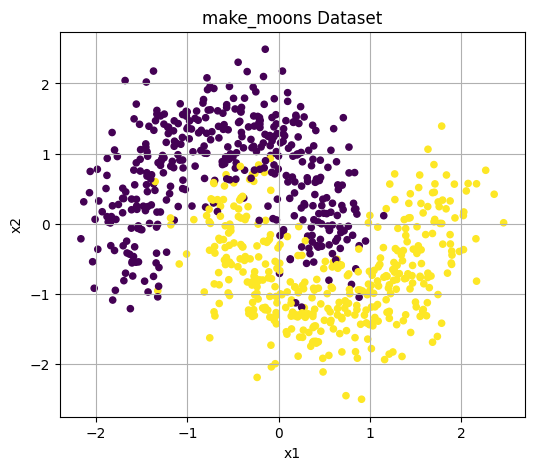

In [ ]:
# ============================================================
# 3. 데이터 분포 확인
# ============================================================

plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("make_moons Dataset")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# 4. MLP 모델 정의
# ============================================================

class MLPActivation(nn.Module):
    def __init__(self, activation_name="relu"):
        super().__init__()
        # 실험 조건에 따라 활성화 함수만 교체하기 위한 조건문
        if activation_name == "relu":
            activation = nn.ReLU
        elif activation_name == "leaky_relu":
            activation = lambda: nn.LeakyReLU(negative_slope=0.01)
        elif activation_name == "sigmoid":
            activation = nn.Sigmoid
        else:
            raise ValueError("지원하지 않는 활성화 함수입니다.")

        self.fc1 = nn.Linear(2, 64)
        self.act1 = activation()

        self.fc2 = nn.Linear(64, 64)
        self.act2 = activation()

        self.fc3 = nn.Linear(64, 2)

        # Dead ReLU와 activation 분포 차이를 관찰하기 위해 동일한 초기화 조건을 사용한다.
        self.initialize_weights()

    def initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
              # 작은 표준편차와 음수 bias를 사용해 ReLU의 dead neuron 발생 가능성 관찰
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
                nn.init.constant_(module.bias, -0.1)

    def forward(self, x, return_activations=False):
        z1 = self.fc1(x)
        a1 = self.act1(z1)

        z2 = self.fc2(a1)
        a2 = self.act2(z2)

        out = self.fc3(a2)
        # activation 분포와 dead neuron 비율 분석을 위해 은닉층 출력을 함께 반환
        if return_activations:
            return out, [a1, a2]

        return out

In [ ]:
# ============================================================
# 5. 평가 함수
# ============================================================

def evaluate_model(model, test_loader):
    # 평가 시에는 gradient 계산이 필요 없으므로 eval 모드와 no_grad를 사용한다.
    model.eval()

    loss_fn = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(test_loader), correct / total

In [ ]:
# ============================================================
# 6. 학습 함수
# ============================================================

def train_model(model, train_loader, test_loader, epochs=300):
    model.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
        "grad_norms": []
    }

    for epoch in range(epochs):
        model.train()

        total_loss = 0.0
        correct = 0
        total = 0
        epoch_grad_norms = []

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            loss.backward()

            # 활성화 함수에 따른 gradient 흐름 차이를 확인하기 위해 gradient norm을 기록한다.
            grad_norm = 0.0
            for param in model.parameters():
                if param.grad is not None:
                    grad_norm += param.grad.norm().item()

            epoch_grad_norms.append(grad_norm)

            optimizer.step()

            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        test_loss, test_acc = evaluate_model(model, test_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["grad_norms"].append(np.mean(epoch_grad_norms))

        if epoch == 0 or (epoch + 1) % 50 == 0:
            print(
                f"Epoch [{epoch+1:03d}/{epochs}] "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Test Loss: {test_loss:.4f} | "
                f"Test Acc: {test_acc:.4f}"
            )

    return history

In [ ]:
# ============================================================
# 7. ReLU / LeakyReLU / Sigmoid 실험 실행
# ============================================================

# ReLU, LeakyReLU, Sigmoid를 동일한 모델 구조와 학습 조건에서 비교
experiments = {
    "ReLU": "relu",
    "LeakyReLU": "leaky_relu",
    "Sigmoid": "sigmoid"
}

histories = {}
models = {}

for name, activation_name in experiments.items():
    print(f"\n========== {name} 실험 시작 ==========")

    set_seed(42)

    model = MLPActivation(
        activation_name=activation_name
    )

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=300
    )

    histories[name] = history
    models[name] = model


========== ReLU 실험 시작 ==========
Epoch [001/300] Train Loss: 0.6933 | Train Acc: 0.4875 | Test Loss: 0.6943 | Test Acc: 0.5000
Epoch [050/300] Train Loss: 0.6934 | Train Acc: 0.4975 | Test Loss: 0.6942 | Test Acc: 0.5000
Epoch [100/300] Train Loss: 0.6933 | Train Acc: 0.4825 | Test Loss: 0.6939 | Test Acc: 0.5000
Epoch [150/300] Train Loss: 0.6932 | Train Acc: 0.5000 | Test Loss: 0.6914 | Test Acc: 0.5000
Epoch [200/300] Train Loss: 0.6933 | Train Acc: 0.5000 | Test Loss: 0.6947 | Test Acc: 0.5000
Epoch [250/300] Train Loss: 0.6934 | Train Acc: 0.4700 | Test Loss: 0.6932 | Test Acc: 0.5000
Epoch [300/300] Train Loss: 0.6935 | Train Acc: 0.4725 | Test Loss: 0.6944 | Test Acc: 0.5000

========== LeakyReLU 실험 시작 ==========
Epoch [001/300] Train Loss: 0.6883 | Train Acc: 0.5250 | Test Loss: 0.6193 | Test Acc: 0.8650
Epoch [050/300] Train Loss: 0.1380 | Train Acc: 0.9437 | Test Loss: 0.0807 | Test Acc: 0.9600
Epoch [100/300] Train Loss: 0.1327 | Train Acc: 0.9513 | Test Loss: 0.0818 | Test

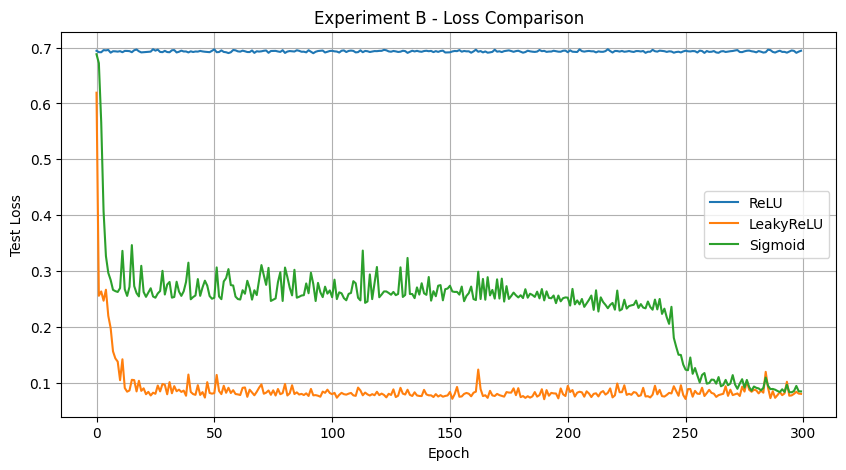

In [ ]:
# ============================================================
# 8. Loss 그래프
# ============================================================

# 활성화 함수별 loss 감소 속도와 학습 정체 여부를 비교한다.
plt.figure(figsize=(10, 5))

for name, history in histories.items():
    plt.plot(history["test_loss"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Experiment B - Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

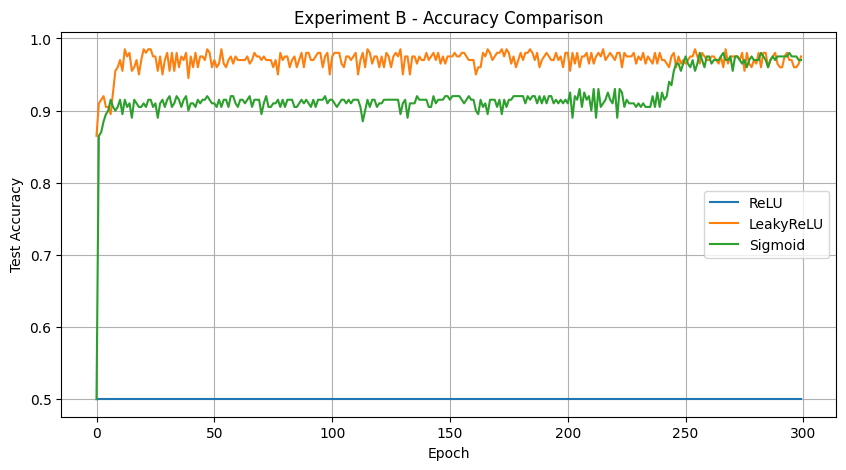

In [ ]:
# ============================================================
# 9. Accuracy 그래프
# ============================================================

# 활성화 함수별 최종 정확도와 수렴 속도를 비교한다.
plt.figure(figsize=(10, 5))

for name, history in histories.items():
    plt.plot(history["test_acc"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Experiment B - Accuracy Comparison")
plt.legend()
plt.grid(True)
plt.show()

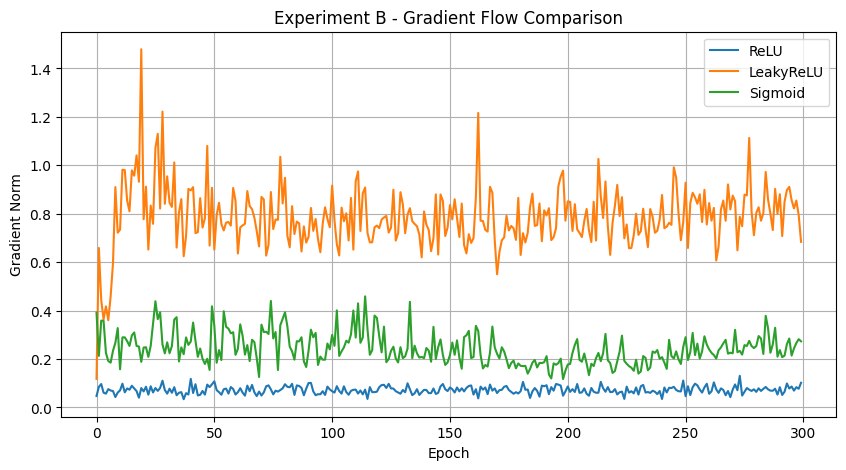

In [ ]:
# ============================================================
# 10. Gradient Norm 그래프
# ============================================================

# Sigmoid의 gradient vanishing과 ReLU 계열의 gradient 흐름 차이를 확인한다.
plt.figure(figsize=(10, 5))

for name, history in histories.items():
    plt.plot(history["grad_norms"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.title("Experiment B - Gradient Flow Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# 11. Activation 수집 함수
# ============================================================

def collect_activations(model, data_loader):
    # 학습이 끝난 모델의 각 은닉층 activation 출력을 수집한다.
    model.eval()

    layer_activations = [[], []]

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)

            outputs, activations = model(
                inputs,
                return_activations=True
            )

            for i, act in enumerate(activations):
                layer_activations[i].append(
                    act.detach().cpu().numpy()
                )

    layer_activations = [
        np.concatenate(acts, axis=0)
        for acts in layer_activations
    ]

    return layer_activations

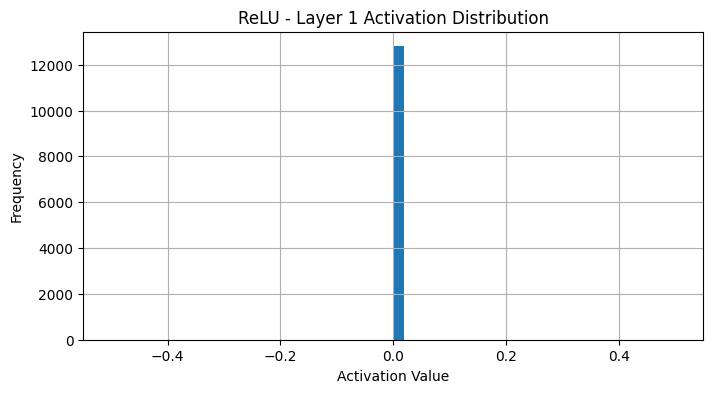

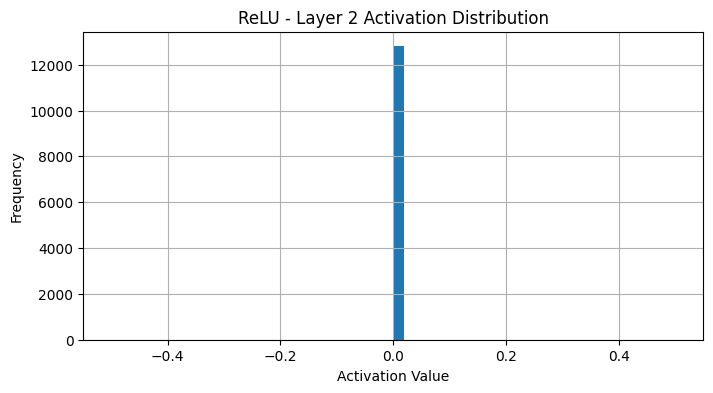

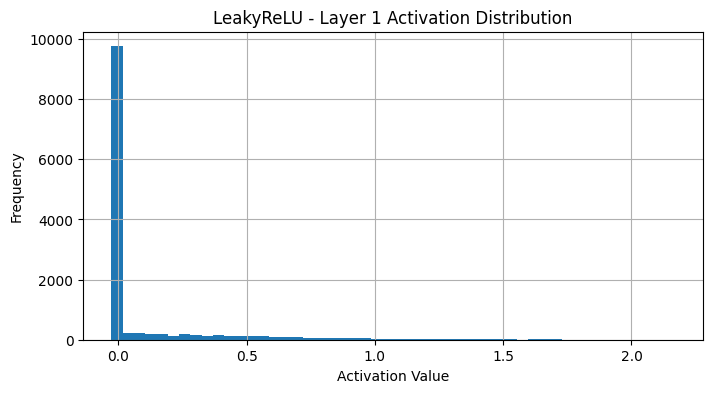

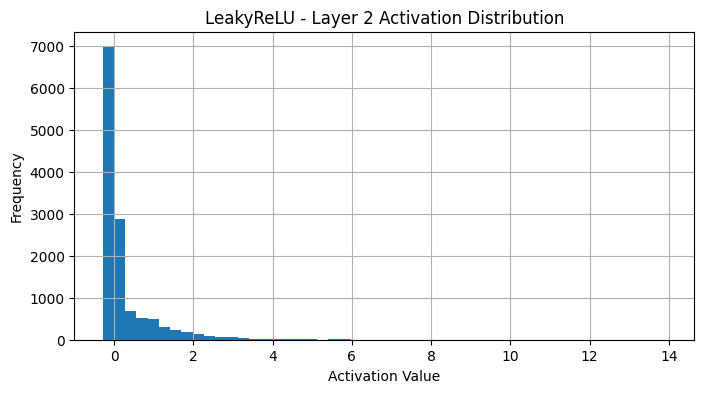

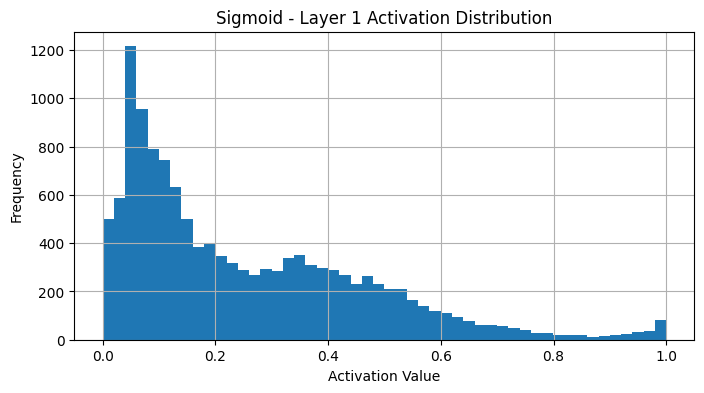

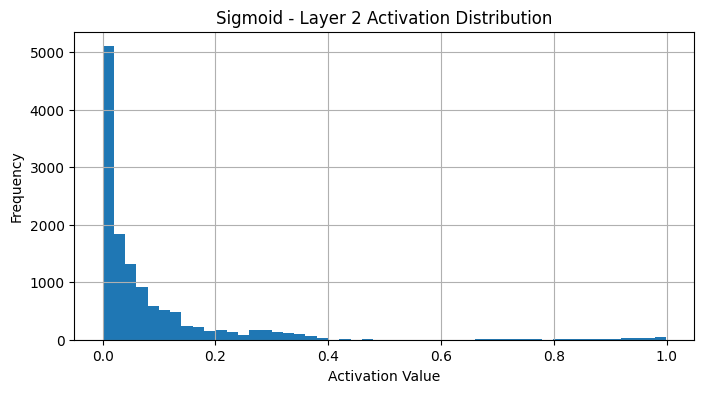

In [ ]:
# ============================================================
# 12. Activation 분포 히스토그램
# ============================================================

for name, model in models.items(): # 각 활성화 함수의 은닉층 출력값 분포 확인
    activations = collect_activations(model, test_loader)

    for layer_idx, layer_act in enumerate(activations):
        plt.figure(figsize=(8, 4))

        plt.hist(layer_act.flatten(), bins=50)

        plt.xlabel("Activation Value")
        plt.ylabel("Frequency")
        plt.title(f"{name} - Layer {layer_idx + 1} Activation Distribution")
        plt.grid(True)
        plt.show()

In [ ]:
# ============================================================
# 13. Dead Neuron 비율 계산
# ============================================================

def calculate_dead_ratio(activations, threshold=1e-6):
    dead_ratios = []

    for layer_act in activations:
        # 각 뉴런이 전체 샘플 중 95% 이상에서 0에 가까운 출력을 내면 dead neuron으로 간주한다.
        zero_ratio_per_neuron = np.mean(
            np.abs(layer_act) < threshold,
            axis=0
        )

        dead_ratio = np.mean(zero_ratio_per_neuron > 0.95)
        dead_ratios.append(dead_ratio)

    return dead_ratios

In [ ]:
# ============================================================
# 14. Dead Neuron 비율 표 생성
# ============================================================

dead_ratio_rows = []

for name, model in models.items():
    activations = collect_activations(model, test_loader)
    dead_ratios = calculate_dead_ratio(activations)

    dead_ratio_rows.append({
        "Activation Function": name,
        "Layer 1 Dead Ratio (%)": round(dead_ratios[0] * 100, 2),
        "Layer 2 Dead Ratio (%)": round(dead_ratios[1] * 100, 2),
        "Final Accuracy (%)": round(histories[name]["test_acc"][-1] * 100, 2),
        "Min Loss": round(min(histories[name]["test_loss"]), 4)
    })

dead_ratio_df = pd.DataFrame(dead_ratio_rows)
dead_ratio_df

,Activation Function,Layer 1 Dead Ratio (%),Layer 2 Dead Ratio (%),Final Accuracy (%),Min Loss
0,ReLU,100.0,100.0,50.0,0.6900
1,LeakyReLU,0.0,0.0,97.5,0.0707
2,Sigmoid,0.0,0.0,97.0,0.0831


In [ ]:
# ============================================================
# 15. Dead Neuron Heatmap
# ============================================================

def plot_dead_neuron_heatmap(activations, title, threshold=1e-6):
    heatmap_data = []

    for layer_act in activations:
        # neuron별 0 출력 비율을 계산하여 heatmap으로 표현한다.
        zero_ratio_per_neuron = np.mean(
            np.abs(layer_act) < threshold,
            axis=0
        )

        heatmap_data.append(zero_ratio_per_neuron)

    heatmap_data = np.array(heatmap_data)

    plt.figure(figsize=(12, 4))
    plt.imshow(heatmap_data, aspect="auto", interpolation="nearest")
    plt.colorbar(label="Zero Activation Ratio")
    plt.xlabel("Neuron Index")
    plt.ylabel("Layer")
    plt.yticks([0, 1], ["Layer 1", "Layer 2"])
    plt.title(title)
    plt.show()

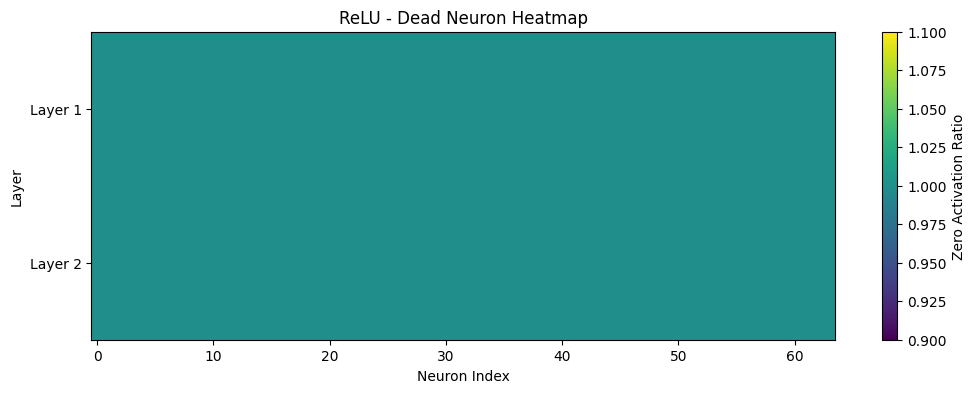

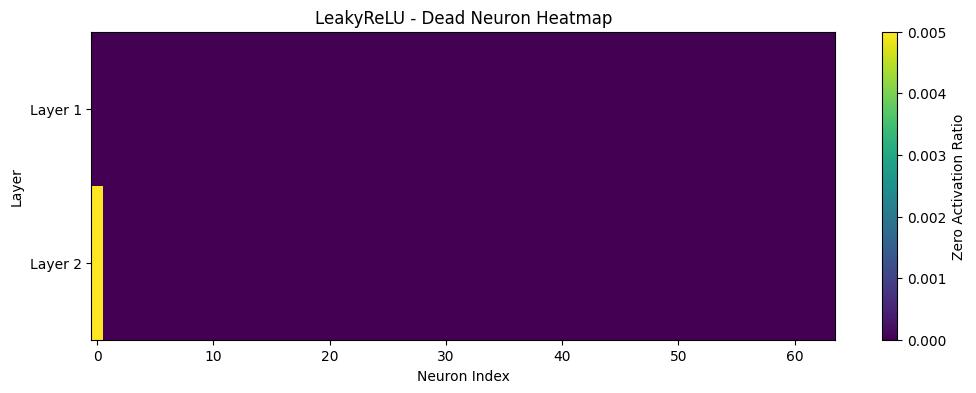

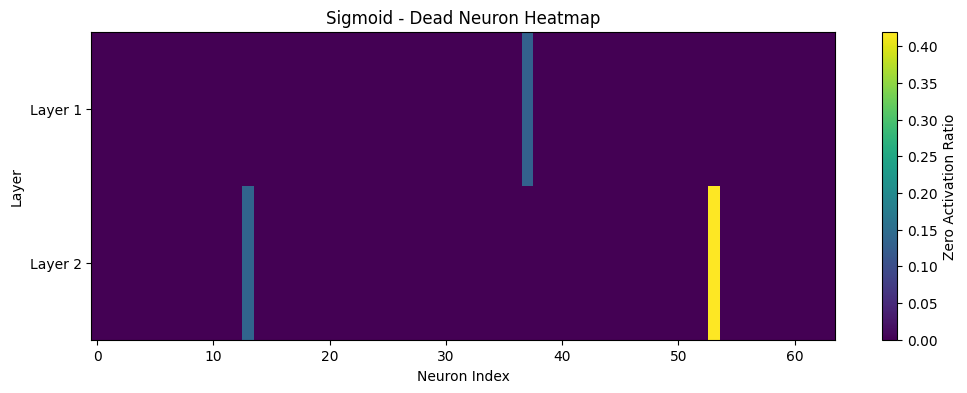

In [ ]:
# ============================================================
# 16. 활성화 함수별 Dead Neuron Heatmap 출력
# ============================================================

for name, model in models.items():
    activations = collect_activations(model, test_loader)

    plot_dead_neuron_heatmap(
        activations,
        title=f"{name} - Dead Neuron Heatmap"
    )

In [ ]:
# ============================================================
# 17. Decision Boundary 시각화
# ============================================================

def plot_decision_boundary(model, X, y, title):
    model.eval()

    X_np = X.numpy()
    y_np = y.numpy()

    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32).to(device)

    with torch.no_grad():
        outputs = model(grid_tensor)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

    preds = preds.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, preds, alpha=0.3)
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, s=20)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.grid(True)
    plt.show()

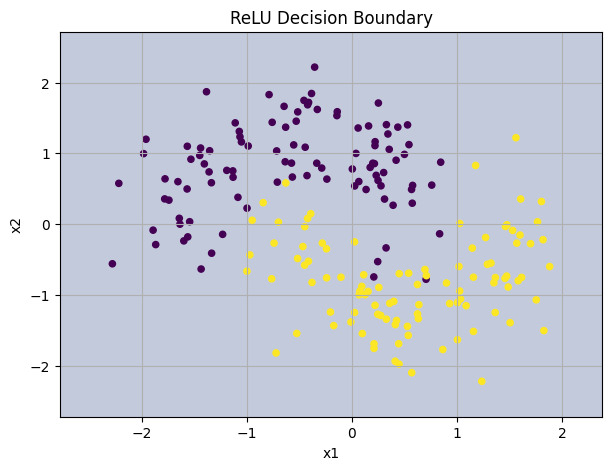

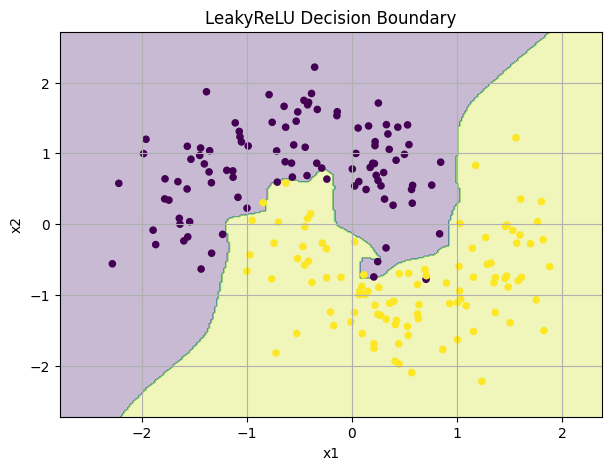

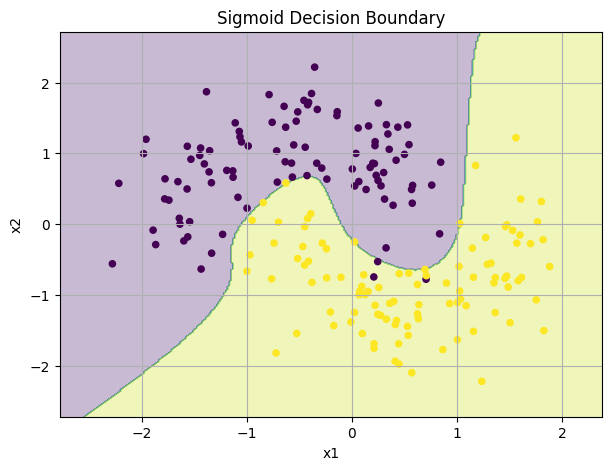

In [ ]:
# ============================================================
# 18. 활성화 함수별 Decision Boundary 출력
# ============================================================

for name, model in models.items():
    plot_decision_boundary(
        model,
        X_test,
        y_test,
        title=f"{name} Decision Boundary"
    )

In [ ]:
# ============================================================
# 19. 정량 비교 표 생성
# ============================================================

def get_convergence_epoch(acc_list):
    final_acc = acc_list[-1]
    target_acc = final_acc * 0.95

    for i, acc in enumerate(acc_list):
        if acc >= target_acc:
            return i + 1

    return len(acc_list)


summary_rows = []

for name, history in histories.items():
    summary_rows.append({
        "Activation Function": name,
        "Final Accuracy (%)": round(history["test_acc"][-1] * 100, 2),
        "Min Loss": round(min(history["test_loss"]), 4),
        "Convergence Epoch": get_convergence_epoch(history["test_acc"]),
        "Final Gradient Norm": round(history["grad_norms"][-1], 6)
    })

summary_B = pd.DataFrame(summary_rows)
summary_B

,Activation Function,Final Accuracy (%),Min Loss,Convergence Epoch,Final Gradient Norm
0,ReLU,50.0,0.6900,1,0.102084
1,LeakyReLU,97.5,0.0707,9,0.684056
2,Sigmoid,97.0,0.0831,202,0.273237
